In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import make_moons
x, y=make_moons(n_samples=500, noise=0.30, random_state=2)

In [3]:
def plot_dataset(x, y, axes):
    plt.plot(x[y==0,0],x[y==0,1],'ro',markersize=3)
    plt.plot(x[y==1,0],x[y==1,1],'g^',markersize=3)
    plt.axis(axes)
    plt.grid(True, which='both')
    plt.xlabel(r"$x_1$", fontsize=18)
    plt.ylabel(r"$x_2$", fontsize=18)

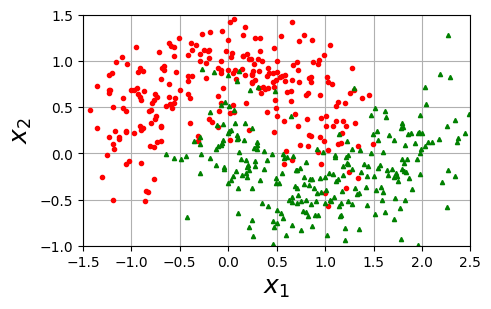

In [4]:
plt.figure(figsize=(5,3))
plot_dataset(x,y,[-1.5,2.5,-1,1.5])
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test=train_test_split(x, y, random_state=1)

In [6]:
from sklearn.tree import DecisionTreeClassifier
tree_clf=DecisionTreeClassifier(random_state=1)
tree_clf.fit(x_train, y_train)
tree_clf.score(x_train, y_train)

1.0

In [7]:
tree_clf.score(x_test, y_test)

0.808

In [8]:
from sklearn.ensemble import BaggingClassifier
base_clf=DecisionTreeClassifier()
bag_clf=BaggingClassifier(base_clf, n_estimators=500, max_samples=100,max_features=2,bootstrap=True,bootstrap_features=False,oob_score=True,random_state=1)
bag_clf.fit(x_train, y_train)
bag_clf.score(x_train, y_train)

0.9413333333333334

In [9]:
bag_clf.score(x_test, y_test)

0.896

In [10]:
bag_clf.oob_score_

0.9093333333333333

In [11]:
bag_clf.oob_decision_function_[:3]

array([[0.25125628, 0.74874372],
       [0.935     , 0.065     ],
       [0.05154639, 0.94845361]])

In [12]:
def plot_decision_boundary(clf, x, y, axes=[-1.5,2.45,-1,1.5]):
    x1s=np.linspace(axes[0], axes[1], 100)
    x2s=np.linspace(axes[2], axes[3], 100)
    x1, x2=np.meshgrid(x1s, x2s)
    x_new=np.c_[x1.ravel(), x2.ravel()]
    y_pred=clf.predict(x_new).reshape(x1.shape)
    plt.contourf(x1, x2, y_pred, alpha=0.2)
    plt.contour(x1, x2, y_pred)
    plot_dataset(x, y, axes)

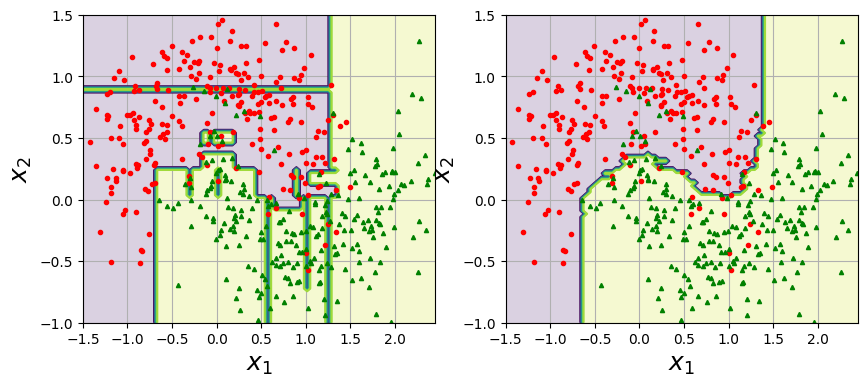

In [13]:
plt.figure(figsize=(10,4))
plt.subplot(121)
plot_decision_boundary(tree_clf, x, y)
plt.subplot(122)
plot_decision_boundary(bag_clf, x, y)
plt.show()